# INSAT-3DR HDF5 Preprocessing Pipeline for RAFT Optical Flow
Colab-ready notebook.

In [3]:
# mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 48.6 MB/s eta 0:00:00


In [5]:
# imports
import os
import h5py
import numpy as np
import cv2
from glob import glob
from scipy.interpolate import griddata
from tqdm import tqdm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pyproj

In [6]:
# Paths
RAW_DIR = "/content/drive/MyDrive/IMD Data/"
OUTPUT_DIR = "/content/drive/MyDrive/INSAT3DR/raft_images/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [7]:
# inspect HDF5 structure

def inspect_h5(file_path):

    with h5py.File(file_path, "r") as f:

        print("="*80)
        print("ROOT KEYS")
        print("="*80)

        for key in f.keys():
            print(key)

        print("\n")

        print("="*80)
        print("DATASETS")
        print("="*80)

        def show(name, obj):

            if isinstance(obj, h5py.Dataset):

                print(
                    f"{name:<60} "
                    f"shape={obj.shape} "
                    f"dtype={obj.dtype}"
                )

        f.visititems(show)

sample_file = glob(RAW_DIR + "*.h5")[0]

inspect_h5(sample_file)

ROOT KEYS
GeoX
GeoX1
GeoY
GeoY1
GeoY2
GreyCount
IMG_MIR
IMG_MIR_RADIANCE
IMG_MIR_TEMP
IMG_SWIR
IMG_SWIR_ALBEDO
IMG_SWIR_RADIANCE
IMG_TIR1
IMG_TIR1_RADIANCE
IMG_TIR1_TEMP
IMG_TIR2
IMG_TIR2_RADIANCE
IMG_TIR2_TEMP
IMG_VIS
IMG_VIS_ALBEDO
IMG_VIS_RADIANCE
IMG_WV
IMG_WV_RADIANCE
IMG_WV_TEMP
Latitude
Latitude_VIS
Longitude
Longitude_VIS
SCAN_LINE_TIME
Sat_Azimuth
Sat_Elevation
Sun_Azimuth
Sun_Elevation
time


DATASETS
GeoX                                                         shape=(2805,) dtype=int32
GeoX1                                                        shape=(11220,) dtype=int32
GeoY                                                         shape=(2816,) dtype=int32
GeoY1                                                        shape=(11264,) dtype=int32
GeoY2                                                        shape=(1409,) dtype=int32
GreyCount                                                    shape=(1024,) dtype=int32
IMG_MIR                                                      

In [8]:
#dataset metadata

def dataset_metadata(file_path):

    with h5py.File(file_path, "r") as f:

        def show(name, obj):

            if isinstance(obj, h5py.Dataset):

                print("\n")
                print("="*60)
                print(name)

                for attr in obj.attrs:

                    print(attr, ":", obj.attrs[attr])

        f.visititems(show)

dataset_metadata(sample_file)



GeoX
CLASS : b'DIMENSION_SCALE'
REFERENCE_LIST : [(<HDF5 object reference>, 2) (<HDF5 object reference>, 2)
 (<HDF5 object reference>, 2) (<HDF5 object reference>, 2)
 (<HDF5 object reference>, 2) (<HDF5 object reference>, 2)
 (<HDF5 object reference>, 2) (<HDF5 object reference>, 2)
 (<HDF5 object reference>, 1) (<HDF5 object reference>, 1)]


GeoX1
CLASS : b'DIMENSION_SCALE'
REFERENCE_LIST : [(<HDF5 object reference>, 2) (<HDF5 object reference>, 2)
 (<HDF5 object reference>, 1) (<HDF5 object reference>, 1)]


GeoY
CLASS : b'DIMENSION_SCALE'
REFERENCE_LIST : [(<HDF5 object reference>, 1) (<HDF5 object reference>, 1)
 (<HDF5 object reference>, 1) (<HDF5 object reference>, 1)
 (<HDF5 object reference>, 1) (<HDF5 object reference>, 1)
 (<HDF5 object reference>, 1) (<HDF5 object reference>, 1)
 (<HDF5 object reference>, 0) (<HDF5 object reference>, 0)]


GeoY1
CLASS : b'DIMENSION_SCALE'
REFERENCE_LIST : [(<HDF5 object reference>, 1) (<HDF5 object reference>, 1)
 (<HDF5 object reference

In [9]:
inspect_h5(sample_file)
dataset_metadata(sample_file)

ROOT KEYS
GeoX
GeoX1
GeoY
GeoY1
GeoY2
GreyCount
IMG_MIR
IMG_MIR_RADIANCE
IMG_MIR_TEMP
IMG_SWIR
IMG_SWIR_ALBEDO
IMG_SWIR_RADIANCE
IMG_TIR1
IMG_TIR1_RADIANCE
IMG_TIR1_TEMP
IMG_TIR2
IMG_TIR2_RADIANCE
IMG_TIR2_TEMP
IMG_VIS
IMG_VIS_ALBEDO
IMG_VIS_RADIANCE
IMG_WV
IMG_WV_RADIANCE
IMG_WV_TEMP
Latitude
Latitude_VIS
Longitude
Longitude_VIS
SCAN_LINE_TIME
Sat_Azimuth
Sat_Elevation
Sun_Azimuth
Sun_Elevation
time


DATASETS
GeoX                                                         shape=(2805,) dtype=int32
GeoX1                                                        shape=(11220,) dtype=int32
GeoY                                                         shape=(2816,) dtype=int32
GeoY1                                                        shape=(11264,) dtype=int32
GeoY2                                                        shape=(1409,) dtype=int32
GreyCount                                                    shape=(1024,) dtype=int32
IMG_MIR                                                      

In [10]:
import os
import h5py
import numpy as np
import cv2
from glob import glob
from scipy.interpolate import griddata
from tqdm import tqdm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pyproj

# dataset reader

IMAGE_DATASET = "IMG_TIR1"
LAT_DATASET = "Latitude"
LON_DATASET = "Longitude"

def read_dataset(file_path):

    with h5py.File(file_path, "r") as f:

        img_ds = f[IMAGE_DATASET]

        img = img_ds[:].astype(np.float32)

        # Squeeze the image array to remove single-dimensional entries (e.g., from (1, H, W) to (H, W))
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.squeeze(axis=0)

        scale = img_ds.attrs.get("scale_factor", 1)

        offset = img_ds.attrs.get("add_offset", 0)

        fill = img_ds.attrs.get("_FillValue", None)

        img = img * scale + offset

        lat = None
        lon = None

        # Try to read Latitude and Longitude based on the initial configuration
        try:
            lat = f[LAT_DATASET][:]
            lon = f[LON_DATASET][:]
        except KeyError:
            # If 'Latitude' or 'Longitude' not found, try '_VIS' versions
            try:
                lat = f["Latitude_VIS"][:]
                lon = f["Longitude_VIS"][:]
            except KeyError:
                # If '_VIS' versions not found, try 'X' and 'Y' datasets
                try:
                    # Read 1D X and Y coordinates
                    x_coords = f["X"][:] # e.g., (3062,)
                    y_coords = f["Y"][:] # e.g., (3207,)

                    # Create 2D meshgrids for the X and Y coordinates in the source projection
                    X_grid, Y_grid = np.meshgrid(x_coords, y_coords)

                    # Define geostationary projection parameters for INSAT-3DR
                    # Assuming standard INSAT-3DR parameters
                    # Satellite height from Earth's center (approx. 35786km from surface + Earth radius 6371km)
                    H = 35785831.0 + 6371000.0 # meters, distance from Earth's center
                    # Central longitude of INSAT-3DR
                    LON_0 = 82.0 # degrees East

                    # Define source (geostationary) CRS and target (WGS84) CRS
                    geos_crs = pyproj.CRS.from_proj4(
                        f" +proj=geos +h={H} +lon_0={LON_0} +x_0=0 +y_0=0 +ellps=WGS84 +units=m +no_defs"
                    )
                    wgs84_crs = pyproj.CRS("EPSG:4326")

                    # Create a transformer
                    transformer = pyproj.Transformer.from_crs(geos_crs, wgs84_crs, always_xy=True)

                    # Transform X_grid and Y_grid (2D arrays) to Longitude and Latitude (also 2D arrays)
                    lon, lat = transformer.transform(X_grid, Y_grid)

                    print(f"Using X and Y datasets and pyproj transformation for coordinates in {os.path.basename(file_path)}")

                except KeyError:
                    raise KeyError(f"Neither '{LAT_DATASET}'/'{LON_DATASET}', 'Latitude_VIS'/'Longitude_VIS', nor 'X'/'Y' datasets found in {file_path}. Cannot determine geographical coordinates.")

        # Ensure lat/lon dimensions match image dimensions (excluding the channel dimension if present)
        img_height, img_width = img.shape[-2:] # Get H, W

        # The resize operation is critical if X and Y were used, or if Latitude/Longitude_VIS were used and different resolutions.
        # After the pyproj transformation, lat and lon will have shape (len(y_coords), len(x_coords)).
        # If len(y_coords) == img_height and len(x_coords) == img_width, no explicit resize is needed here, but the check handles cases where dimensions might differ or for other dataset types.
        if lat.shape != (img_height, img_width) or lon.shape != (img_height, img_width):
            print(f"Resizing latitude/longitude for {os.path.basename(file_path)} from {lat.shape} to ({img_height}, {img_width}) to match image dimensions.")
            # Ensure data type is float32 for cv2.resize
            lat = cv2.resize(lat.astype(np.float32), (img_width, img_height), interpolation=cv2.INTER_LINEAR)
            lon = cv2.resize(lon.astype(np.float32), (img_width, img_height), interpolation=cv2.INTER_LINEAR)

    return img, lat, lon, fill

In [11]:
# cleaning updated for robustness
def clean_data(img, lat, lon, fill):
    if fill is not None:
        img[img == fill] = np.nan

    img = img.astype(np.float32)

    # Ensure lat/lon are treated as float32 for consistency in finite checks
    lat = lat.astype(np.float32)
    lon = lon.astype(np.float32)

    valid = (
        np.isfinite(img) &
        np.isfinite(lat) &
        np.isfinite(lon) &
        (lat >= -90) & (lat <= 90) &
        (lon >= -180) & (lon <= 180)
    )

    return valid

In [12]:
# target grid

TARGET_SIZE = 512

LAT_MIN = 0
LAT_MAX = 40

LON_MIN = 50
LON_MAX = 100

target_lon, target_lat = np.meshgrid(
    np.linspace(LON_MIN, LON_MAX, TARGET_SIZE),
    np.linspace(LAT_MIN, LAT_MAX, TARGET_SIZE)
)

In [13]:
# regridding with safety check
def regrid_image(img, lat, lon, valid):
    if np.sum(valid) == 0:
        print("CRITICAL: No valid points found for interpolation. Returning empty grid.")
        return np.zeros((TARGET_SIZE, TARGET_SIZE), dtype=np.float32)

    points = np.column_stack(
        (
            lon[valid],
            lat[valid]
        )
    )

    values = img[valid]

    try:
        regridded = griddata(
            points,
            values,
            (target_lon, target_lat),
            method='linear'
        )
        # Fill potential NaNs from linear interpolation (out of bounds)
        regridded = np.nan_to_num(regridded, nan=np.nanmin(values) if values.size > 0 else 0)
        return regridded
    except Exception as e:
        print(f"Interpolation failed: {e}")
        return np.zeros((TARGET_SIZE, TARGET_SIZE), dtype=np.float32)

In [14]:
# normalize

def normalize(img):

    img = np.nan_to_num(img)

    p1 = np.percentile(img, 1)
    p99 = np.percentile(img, 99)

    img = np.clip(img, p1, p99)

    img = (img - img.min()) / (img.max() - img.min())

    img = (img * 255).astype(np.uint8)

    return img

In [15]:
# convert to RGB
def to_rgb(img):

    return np.stack(
        [img, img, img],
        axis=-1
    )

In [16]:
import os
import h5py
import numpy as np
import cv2
from glob import glob
from scipy.interpolate import griddata
from tqdm import tqdm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pyproj

# full pipeline

def process_file(file_path):

    img, lat, lon, fill = read_dataset(file_path)

    # Replace inf values with NaN before cleaning
    lat[np.isinf(lat)] = np.nan
    lon[np.isinf(lon)] = np.nan

    # Debugging: print stats after read_dataset
    print(f"\n--- Debugging {os.path.basename(file_path)} after read_dataset ---")
    print(f"Img shape: {img.shape}, min: {np.nanmin(img) if np.isfinite(img).any() else 'NaN'}, max: {np.nanmax(img) if np.isfinite(img).any() else 'NaN'}, nan count: {np.sum(np.isnan(img))}")
    print(f"Lat shape: {lat.shape}, min: {np.nanmin(lat) if np.isfinite(lat).any() else 'NaN'}, max: {np.nanmax(lat) if np.isfinite(lat).any() else 'NaN'}, nan count: {np.sum(np.isnan(lat))}")
    print(f"Lon shape: {lon.shape}, min: {np.nanmin(lon) if np.isfinite(lon).any() else 'NaN'}, max: {np.nanmax(lon) if np.isfinite(lon).any() else 'NaN'}, nan count: {np.sum(np.isnan(lon))}")

    valid = clean_data(
        img,
        lat,
        lon,
        fill
    )

    # Debugging: print stats after clean_data
    print(f"Valid points count after clean_data: {np.sum(valid)}")
    if np.sum(valid) == 0:
        print("No valid points found! Check ranges and NaN values.")
        # Optionally, you can add more detailed checks here, e.g., print ranges of lat/lon before filtering.
        print(f"Original Lat range: [{np.nanmin(lat) if np.isfinite(lat).any() else 'NaN'}, {np.nanmax(lat) if np.isfinite(lat).any() else 'NaN'}]")
        print(f"Original Lon range: [{np.nanmin(lon) if np.isfinite(lon).any() else 'NaN'}, {np.nanmax(lon) if np.isfinite(lon).any() else 'NaN'}]")

    img = regrid_image(
        img,
        lat,
        lon,
        valid
    )

    img = normalize(img)

    img = to_rgb(img)

    return img

In [22]:
# generate RAFT images with skip logic for empty data

files = sorted(
    glob(RAW_DIR + "*.h5")
)

print("Files found:", len(files))

for idx, file_path in enumerate(tqdm(files)):
    try:
        img_rgb = process_file(file_path)

        # Check if the process_file returned an empty/black frame due to the 'No points' issue
        # Our updated regrid_image returns zeros if no points are found
        if np.all(img_rgb == 0):
            print(f"Skipping {os.path.basename(file_path)}: No valid data points found in target region.")
            continue

        save_path = f"{OUTPUT_DIR}/frame_{idx:05d}.png"

        cv2.imwrite(
            save_path,
            cv2.cvtColor(
                img_rgb,
                cv2.COLOR_RGB2BGR
            )
        )
    except Exception as e:
        print(f"Error processing {os.path.basename(file_path)}: {e}")

Files:
 10


  0%|          | 0/10 [00:00<?, ?it/s]

Using X and Y datasets and pyproj transformation for coordinates in 3RIMG_11JUN2026_0015_L1C_SGP_V01R00.h5

--- Debugging 3RIMG_11JUN2026_0015_L1C_SGP_V01R00.h5 after read_dataset ---
Img shape: (3207, 3062), min: 479.0, max: 955.0, nan count: 0
Lat shape: (3207, 3062), min: -82.37321830954023, max: 82.37321830954023, nan count: 3776404
Lon shape: (3207, 3062), min: -0.2835428936062702, max: 164.28354289360627, nan count: 3776404
Valid points count after clean_data: 6043430


 10%|█         | 1/10 [02:28<22:12, 148.09s/it]

Using X and Y datasets and pyproj transformation for coordinates in 3RIMG_11JUN2026_0045_L1C_SGP_V01R00.h5

--- Debugging 3RIMG_11JUN2026_0045_L1C_SGP_V01R00.h5 after read_dataset ---
Img shape: (3207, 3062), min: 475.0, max: 952.0, nan count: 0
Lat shape: (3207, 3062), min: -82.37321830954023, max: 82.37321830954023, nan count: 3776404
Lon shape: (3207, 3062), min: -0.2835428936062702, max: 164.28354289360627, nan count: 3776404
Valid points count after clean_data: 6043430


...

Using X and Y datasets and pyproj transformation for coordinates in 3RIMG_11JUN2026_0245_L1C_SGP_V01R00.h5

--- Debugging 3RIMG_11JUN2026_0245_L1C_SGP_V01R00.h5 after read_dataset ---
Img shape: (3207, 3062), min: 368.0, max: 950.0, nan count: 0
Lat shape: (3207, 3062), min: -82.37321830954023, max: 82.37321830954023, nan count: 3776404
Lon shape: (3207, 3062), min: -0.2835428936062702, max: 164.28354289360627, nan count: 3776404
Valid points count after clean_data: 6043430


 60%|██████    | 6/10 [15:11<10:12, 153.15s/it]

Using X and Y datasets and pyproj transformation for coordinates in 3RIMG_11JUN2026_0315_L1C_SGP_V01R00.h5

--- Debugging 3RIMG_11JUN2026_0315_L1C_SGP_V01R00.h5 after read_dataset ---
Img shape: (3207, 3062), min: 341.0, max: 955.0, nan count: 0
Lat shape: (3207, 3062), min: -82.37321830954023, max: 82.37321830954023, nan count: 3776404
Lon shape: (3207, 3062), min: -0.2835428936062702, max: 164.28354289360627, nan count: 3776404
Valid points count after clean_data: 6043430


 70%|███████   | 7/10 [17:41<07:34, 151.66s/it]


ValueError: cannot convert float NaN to integer

Using X and Y datasets and pyproj transformation for coordinates in 3RIMG_11JUN2026_0015_L1C_SGP_V01R00.h5

--- Debugging 3RIMG_11JUN2026_0015_L1C_SGP_V01R00.h5 after read_dataset ---
Img shape: (3207, 3062), min: 479.0, max: 955.0, nan count: 0
Lat shape: (3207, 3062), min: -82.37321830954023, max: 82.37321830954023, nan count: 3776404
Lon shape: (3207, 3062), min: -0.2835428936062702, max: 164.28354289360627, nan count: 3776404
Valid points count after clean_data: 6043430


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


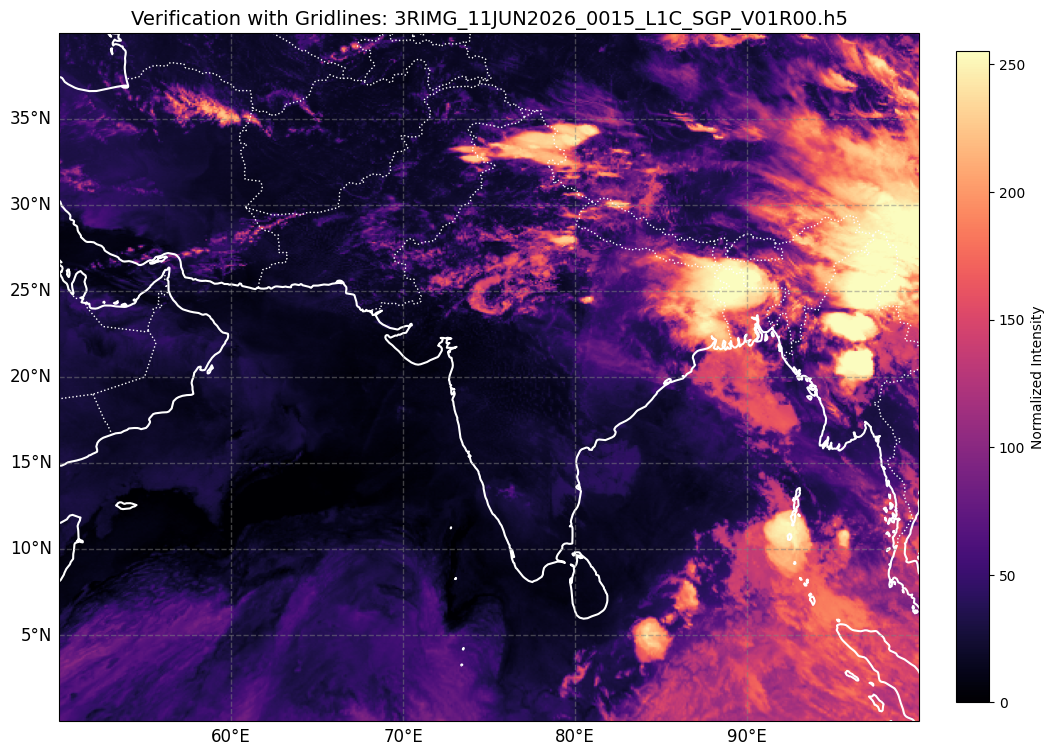

In [21]:
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# cartopy verification with scales
files = sorted(glob(os.path.join(RAW_DIR, "*.h5")))

if not files:
    print("No files found in RAW_DIR!")
else:
    img = process_file(files[0])

    fig = plt.figure(figsize=(12, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Add coastlines and borders
    ax.coastlines(resolution='50m', color='white', linewidth=1.5)
    import cartopy.feature as cfeature
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='white')

    # Display image
    im = ax.imshow(
        img[:,:,0],
        extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
        origin="upper",
        transform=ccrs.PlateCarree(),
        cmap='magma'
    )

    # Add Gridlines and Labels (the 'scale')
    gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}

    plt.colorbar(im, ax=ax, label='Normalized Intensity', fraction=0.035, pad=0.04)
    plt.title(f"Verification with Gridlines: {os.path.basename(files[0])}", fontsize=14)
    plt.show()

In [22]:
# RAFT pairs

images = sorted(
    glob(
        OUTPUT_DIR + "/*.png"
    )
)

pairs = [
    (images[i], images[i+1])
    for i in range(len(images)-1)
]

print("RAFT Pairs:", len(pairs))

RAFT Pairs: 6


### Save Images as a Single NumPy Tensor
This step aggregates all generated PNGs into a single 4D NumPy array and saves it for easier loading into deep learning models.

In [23]:
import numpy as np
import cv2
import os

# Load all processed PNGs into a list
image_list = []
for img_path in sorted(glob(os.path.join(OUTPUT_DIR, "*.png"))):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    image_list.append(img)

if image_list:
    # Create a 4D tensor: (Number of frames, Height, Width, Channels)
    image_tensor = np.array(image_list)

    tensor_save_path = os.path.join(OUTPUT_DIR, "insat3dr_raft_tensor.npy")
    np.save(tensor_save_path, image_tensor)

    print(f"Tensor saved successfully!")
    print(f"Shape: {image_tensor.shape}")
    print(f"Path: {tensor_save_path}")
else:
    print("No PNG images found in the output directory to create a tensor.")

Tensor saved successfully!
Shape: (7, 512, 512, 3)
Path: /content/drive/MyDrive/INSAT3DR/raft_images/insat3dr_raft_tensor.npy
